# LAB-8
#Convolutional Neural Networks

## Experiment 0 — Setting Up


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cpu | device: cpu


## Experiment 1 — How PyTorch Stores an Image


In [2]:
x = torch.rand(1, 3, 32, 32)

print("tensor shape :", x.shape)
print("N (batch)    :", x.shape[0])
print("C (channels) :", x.shape[1])
print("H (height)   :", x.shape[2])
print("W (width)    :", x.shape[3])

tensor shape : torch.Size([1, 3, 32, 32])
N (batch)    : 1
C (channels) : 3
H (height)   : 32
W (width)    : 32


## Experiment 2 — Convolution by Hand and by PyTorch


In [3]:
X = torch.tensor([[1., 2., 0.],
                  [0., 1., 3.],
                  [2., 1., 0.]])

K = torch.tensor([[ 1., 0.],
                  [-1., 1.]])

# Convolution definition Z(i,j) = b + sum_m sum_n X(i+m,j+n)*K(m,n), written out as two loops.
manual = torch.zeros(2, 2)
for i in range(2):
    for j in range(2):
        patch = X[i:i+2, j:j+2]
        manual[i, j] = (patch * K).sum()

print("hand-computed:\n", manual)

# The same thing, in one call. conv2d wants (N, C, H, W) and (out, in, kH, kW).
out = F.conv2d(X.view(1, 1, 3, 3), K.view(1, 1, 2, 2))
print("F.conv2d     :\n", out.view(2, 2))
print("identical    :", torch.allclose(manual, out.view(2, 2)))

hand-computed:
 tensor([[ 2.,  4.],
        [-1.,  0.]])
F.conv2d     :
 tensor([[ 2.,  4.],
        [-1.,  0.]])
identical    : True


## Experiment 3 — Stride, Padding and the Output-Size Formula
Aim: test the output-size formula H_out = floor((H + 2P - K) / S) + 1 against the shapes PyTorch actually produces.

In [4]:
def output_size(H, K, S, P):
    """Output-size formula: floor((H + 2P - K) / S) + 1."""
    return (H + 2*P - K) // S + 1

settings = [(32, 3, 1, 1),   # Numerical 2
            (64, 5, 2, 2),   # Q1
            (28, 3, 1, 0),   # no padding shrinks the map
            (32, 3, 1, 2)]   # generous padding grows it

# lowercase names here so the X and K of Experiment 2 stay untouched
for h, k, s, p in settings:
    layer    = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p)
    actual   = layer(torch.zeros(1, 1, h, h)).shape[-1]
    expected = output_size(h, k, s, p)
    print(f"H={h:3d} K={k} S={s} P={p}  ->  formula {expected:3d}"
          f"   PyTorch {actual:3d}   {'ok' if expected == actual else 'MISMATCH'}")

H= 32 K=3 S=1 P=1  ->  formula  32   PyTorch  32   ok
H= 64 K=5 S=2 P=2  ->  formula  32   PyTorch  32   ok
H= 28 K=3 S=1 P=0  ->  formula  26   PyTorch  26   ok
H= 32 K=3 S=1 P=2  ->  formula  34   PyTorch  34   ok


## Experiment 4 — ReLU and Its Gradient


In [5]:
fm = torch.tensor([[-2., 3., -1.],
                   [ 4., 0., -5.]])

print("after ReLU:\n", F.relu(fm))

z = fm.clone().requires_grad_(True)
F.relu(z).sum().backward()
print("d(ReLU)/dz:\n", z.grad)

after ReLU:
 tensor([[0., 3., 0.],
        [4., 0., 0.]])
d(ReLU)/dz:
 tensor([[0., 1., 0.],
        [1., 0., 0.]])


## Experiment 5 — Max and Average Pooling


In [6]:
M = torch.tensor([[1., 9., 2., 4.],
                  [3., 5., 7., 0.],
                  [8., 6., 2., 1.],
                  [4., 3., 9., 5.]]).view(1, 1, 4, 4)

print("max pooling:\n", F.max_pool2d(M, kernel_size=2, stride=2).view(2, 2))
print("avg pooling:\n", F.avg_pool2d(M, kernel_size=2, stride=2).view(2, 2))

max pooling:
 tensor([[9., 7.],
        [8., 9.]])
avg pooling:
 tensor([[4.5000, 3.2500],
        [5.2500, 4.2500]])


## Experiment 6 — How Gradient Flows Back Through Pooling


In [7]:
upstream = torch.tensor([[1., 2.],
                         [3., 4.]]).view(1, 1, 2, 2)

for name, pool in [("max", F.max_pool2d), ("avg", F.avg_pool2d)]:
    x = M.clone().requires_grad_(True)
    y = pool(x, kernel_size=2, stride=2)
    y.backward(upstream)
    print(f"gradient reaching the input, {name} pooling:")
    print(x.grad.view(4, 4), "\n")

gradient reaching the input, max pooling:
tensor([[0., 1., 0., 0.],
        [0., 0., 2., 0.],
        [3., 0., 0., 0.],
        [0., 0., 4., 0.]]) 

gradient reaching the input, avg pooling:
tensor([[0.2500, 0.2500, 0.5000, 0.5000],
        [0.2500, 0.2500, 0.5000, 0.5000],
        [0.7500, 0.7500, 1.0000, 1.0000],
        [0.7500, 0.7500, 1.0000, 1.0000]]) 



## Experiment 7 — Backpropagation Through a Convolution Layer


In [8]:
X_grad = X.view(1, 1, 3, 3).clone().requires_grad_(True)

conv = nn.Conv2d(1, 1, kernel_size=2)
with torch.no_grad():                 # install the kernel from Section 4.2
    conv.weight.copy_(K.view(1, 1, 2, 2))
    conv.bias.zero_()

delta = torch.tensor([[1., 0.],
                      [0., 1.]]).view(1, 1, 2, 2)

Z = conv(X_grad)
Z.backward(delta)                     # delta is dL/dZ, supplied by hand

print("dL/db =", conv.bias.grad.item())
print("dL/dK =\n", conv.weight.grad.view(2, 2))
print("dL/dX =\n", X_grad.grad.view(3, 3))

dL/db = 2.0
dL/dK =
 tensor([[2., 5.],
        [1., 1.]])
dL/dX =
 tensor([[ 1.,  0.,  0.],
        [-1.,  2.,  0.],
        [ 0., -1.,  1.]])


## Experiment 8 — Parameters, Receptive Field and Cost


In [9]:
# Numerical 8: 3x3 kernels, 32 in-channels, 64 filters.
layer = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
print("parameters:", sum(p.numel() for p in layer.parameters()),
      " = 3*3*32*64 weights + 64 biases")

# Q7: one 5x5 layer against two stacked 3x3 layers, single channel, no bias.
one_5x5 = nn.Conv2d(1, 1, 5, bias=False)
two_3x3 = nn.Sequential(nn.Conv2d(1, 1, 3, bias=False),
                        nn.Conv2d(1, 1, 3, bias=False))
print("one 5x5:", sum(p.numel() for p in one_5x5.parameters()), "weights")
print("two 3x3:", sum(p.numel() for p in two_3x3.parameters()), "weights")

# Section 6.1: the receptive-field recurrence.
def receptive_field(kernels, strides):
    r, jump = 1, 1
    for k, s in zip(kernels, strides):
        r += (k - 1) * jump
        jump *= s
    return r

print("RF, two 3x3 stride-1 layers  :", receptive_field([3, 3], [1, 1]))
print("RF, three 3x3 stride-1 layers:", receptive_field([3, 3, 3], [1, 1, 1]))

# Q9: multiply-accumulate count of a 3x3, 1 -> 16 layer on a 32x32 map.
H_out = W_out = 32
print("MACs:", H_out * W_out * 3 * 3 * 1 * 16)

parameters: 18496  = 3*3*32*64 weights + 64 biases
one 5x5: 25 weights
two 3x3: 18 weights
RF, two 3x3 stride-1 layers  : 5
RF, three 3x3 stride-1 layers: 7
MACs: 147456


## Experiment 9 — Loading CIFAR-10


In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True,
                                         download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root="./data", train=False,
                                         download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=64, shuffle=False)

classes = ("plane", "car", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck")

print(len(train_set), "training images |", len(test_set), "test images")
print("one image:", train_set[0][0].shape, "| label:", classes[train_set[0][1]])

100%|██████████| 170M/170M [00:14<00:00, 11.7MB/s]


50000 training images | 10000 test images
one image: torch.Size([3, 32, 32]) | label: frog


Look at a batch before training on it. The de-normalisation step `img / 2 + 0.5` undoes the transform, and `permute` reorders the channels for matplotlib.

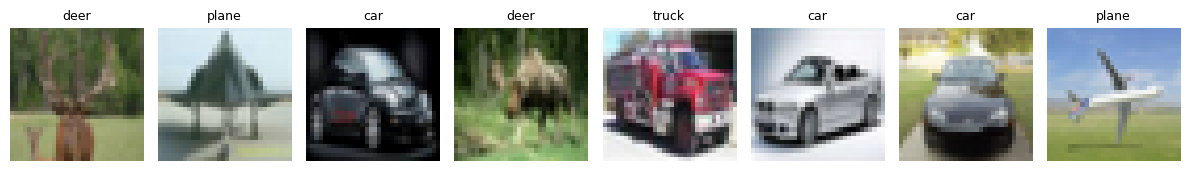

In [11]:
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, images[:8], labels[:8]):
    ax.imshow((img / 2 + 0.5).permute(1, 2, 0))
    ax.set_title(classes[lab], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Experiment 10 — Building the CNN



In [12]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 8 * 8, 128)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # 3x32x32  -> 16x16x16
        x = self.pool(F.relu(self.conv2(x)))    # 16x16x16 -> 32x8x8
        x = torch.flatten(x, 1)                 # 32x8x8   -> 2048
        x = F.relu(self.fc1(x))
        return self.fc2(x)                      # raw logits, no softmax

model = SmallCNN().to(device)
print(model)

SmallCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Now push one image through it step by step. This is the shape trace of Section 7, carried out on a real tensor rather than on paper.

In [13]:
x = torch.rand(1, 3, 32, 32).to(device)

print("input        ", tuple(x.shape))
h = model.conv1(x);          print("after conv1  ", tuple(h.shape))
h = model.pool(F.relu(h));   print("after pool1  ", tuple(h.shape))
h = model.conv2(h);          print("after conv2  ", tuple(h.shape))
h = model.pool(F.relu(h));   print("after pool2  ", tuple(h.shape))
h = torch.flatten(h, 1);     print("after flatten", tuple(h.shape))
print("logits       ", tuple(model(x).shape))

print()
for name, p in model.named_parameters():
    print(f"{name:12s} {str(tuple(p.shape)):18s} {p.numel():>7d}")
print("total parameters:", sum(p.numel() for p in model.parameters()))

input         (1, 3, 32, 32)
after conv1   (1, 16, 32, 32)
after pool1   (1, 16, 16, 16)
after conv2   (1, 32, 16, 16)
after pool2   (1, 32, 8, 8)
after flatten (1, 2048)
logits        (1, 10)

conv1.weight (16, 3, 3, 3)          432
conv1.bias   (16,)                   16
conv2.weight (32, 16, 3, 3)        4608
conv2.bias   (32,)                   32
fc1.weight   (128, 2048)         262144
fc1.bias     (128,)                 128
fc2.weight   (10, 128)             1280
fc2.bias     (10,)                   10
total parameters: 268650


## Experiment 11 — Training and Evaluation


In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 5

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                    # clear last batch's gradients
        outputs = model(images)                  # forward pass
        loss = criterion(outputs, labels)        # loss
        loss.backward()                          # backward pass
        optimizer.step()                         # parameter update

        running += loss.item() * images.size(0)

    print(f"epoch {epoch}   training loss {running / len(train_set):.4f}")

epoch 1   training loss 1.4509
epoch 2   training loss 1.0938
epoch 3   training loss 0.9442
epoch 4   training loss 0.8487
epoch 5   training loss 0.7734


Evaluation switches the model to eval mode and disables gradient tracking, which is both faster and safer — nothing in the test loop should ever change a weight.

In [15]:
model.eval()
correct = total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predicted = model(images).argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

print(f"test accuracy: {100 * correct / total:.2f}%")

test accuracy: 69.49%


A single accuracy number hides which classes the network finds hard. Break it down:

In [16]:
correct_per_class = torch.zeros(10)
total_per_class   = torch.zeros(10)

with torch.no_grad():
    for images, labels in test_loader:
        predicted = model(images.to(device)).argmax(dim=1).cpu()
        for c in range(10):
            mask = labels == c
            correct_per_class[c] += (predicted[mask] == c).sum()
            total_per_class[c]   += mask.sum()

for c in range(10):
    print(f"{classes[c]:6s} {100 * correct_per_class[c] / total_per_class[c]:5.1f}%")

plane   75.7%
car     78.7%
bird    44.9%
cat     51.5%
deer    69.6%
dog     61.0%
frog    79.7%
horse   73.5%
ship    80.1%
truck   80.2%


## Experiment 12 — Looking Inside the Trained Network


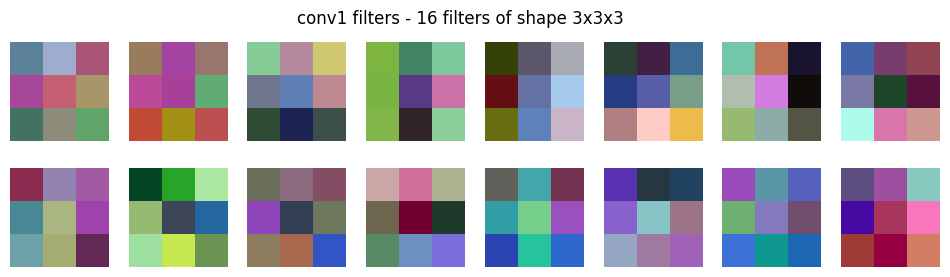

In [17]:
w = model.conv1.weight.data.cpu()
w = (w - w.min()) / (w.max() - w.min())      # rescale to [0, 1] for display

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, filt in zip(axes.flat, w):
    ax.imshow(filt.permute(1, 2, 0))
    ax.axis("off")
plt.suptitle("conv1 filters - 16 filters of shape 3x3x3")
plt.show()

Then look at what those filters produce on a real image. Each of the 16 feature maps is a 32x32 response surface: bright where that filter found its pattern, dark where it did not.

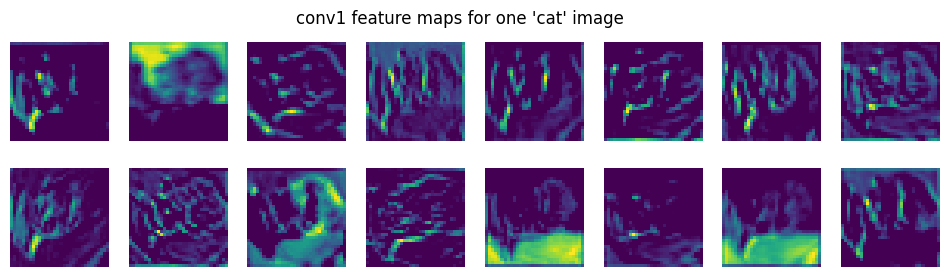

In [18]:
image, label = test_set[0]

with torch.no_grad():
    maps = F.relu(model.conv1(image.unsqueeze(0).to(device))).cpu()[0]

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, fmap in zip(axes.flat, maps):
    ax.imshow(fmap, cmap="viridis")
    ax.axis("off")
plt.suptitle(f"conv1 feature maps for one '{classes[label]}' image")
plt.show()

## Lab Exercises
Complete these in the same notebook. Record the output of each and, where the exercise asks for it, a one-line explanation of why the result came out that way.

1.  Change the kernel in Experiment 2 to `[[1, 1], [1, 1]]` and predict the new feature map before running the cell. What pattern does this filter detect?
2.  Add the settings `(32, 4, 1, 1)` and `(7, 3, 2, 0)` to Experiment 3. Explain the second result using the floor in `H_out = floor((H + 2P - K) / S) + 1`.
3.  In Experiment 6, change the upstream gradient to `[[1, 1], [1, 1]]` and describe how the max-pooling gradient changes and how the average-pooling gradient changes.
4.  Modify Experiment 7 to use a 3x3 kernel on a 4x4 input with an upstream gradient of all ones. Predict `dL/db` before running it, then check.
5.  Add a third convolution layer (32 -> 64, 3x3, padding 1) and a third pooling layer to `SmallCNN`. Work out the new flattened size on paper, adjust `fc1`, and confirm with a shape trace.
6.  Replace both `nn.MaxPool2d` layers with `nn.AvgPool2d`, retrain for 5 epochs, and compare the test accuracy. Which pooling rule works better here, and does the difference survive a change of random seed?
7.  Set `padding=0` in both convolution layers of `SmallCNN`. Trace the shapes, fix `fc1`, and state how many pixels of the border were lost.
8.  Train for 15 epochs instead of 5 and plot training loss against test accuracy per epoch. Identify the epoch at which the two curves start to diverge.
9.  Add `transforms.RandomHorizontalFlip()` to the training transform only, retrain, and report the change in test accuracy. Explain why this transform is applied to the training set but not the test set.
10. Count the multiply-accumulate operations of `conv1` and `conv2` using `MACs = H_out x W_out x K x K x C_in x C_out`, then compare the two figures with the parameter counts printed in Experiment 10. Which layer is the more expensive, and which is the larger?

### Lab Exercise 1: Kernel Change in Experiment 2

In [27]:
# Recreating Experiment 2 context for Lab Exercise 1
X = torch.tensor([[1., 2., 0.],
                  [0., 1., 3.],
                  [2., 1., 0.]])

# New kernel for Lab Exercise 1
K_new = torch.tensor([[1., 1.],
                      [1., 1.]])

manual_new = torch.zeros(2, 2)
for i in range(2):
    for j in range(2):
        patch = X[i:i+2, j:j+2]
        manual_new[i, j] = (patch * K_new).sum()

print("hand-computed (new kernel):\n", manual_new)

# The same thing, in one call. conv2d wants (N, C, H, W) and (out, in, kH, kW).
out_new = F.conv2d(X.view(1, 1, 3, 3), K_new.view(1, 1, 2, 2))
print("F.conv2d (new kernel)     :\n", out_new.view(2, 2))
print("identical                 :", torch.allclose(manual_new, out_new.view(2, 2)))

hand-computed (new kernel):
 tensor([[4., 6.],
        [4., 5.]])
F.conv2d (new kernel)     :
 tensor([[4., 6.],
        [4., 5.]])
identical                 : True


**Predicted Output:**
```
hand-computed (new kernel):
 tensor([[4., 6.],
        [4., 5.]])
F.conv2d (new kernel)     :
 tensor([[4., 6.],
        [4., 5.]])
identical                 : True
```
**Explanation:** This filter acts as a sum detector for each 2x2 neighborhood in the input, effectively calculating the sum of pixel intensities within that window.

### Lab Exercise 2: New Settings for Output Size in Experiment 3

In [22]:
# Recreating Experiment 3 context for Lab Exercise 2
def output_size(H, K, S, P):
    """Output-size formula: floor((H + 2P - K) / S) + 1."""
    return (H + 2*P - K) // S + 1

settings_ex2 = [(32, 3, 1, 1),   # Numerical 2
                (64, 5, 2, 2),   # Q1
                (28, 3, 1, 0),   # no padding shrinks the map
                (32, 3, 1, 2),   # generous padding grows it
                (32, 4, 1, 1),   # New setting 1 for Lab Exercise 2
                (7, 3, 2, 0)]    # New setting 2 for Lab Exercise 2

for h, k, s, p in settings_ex2:
    layer    = nn.Conv2d(1, 1, kernel_size=k, stride=s, padding=p)
    actual   = layer(torch.zeros(1, 1, h, h)).shape[-1]
    expected = output_size(h, k, s, p)
    print(f"H={h:3d} K={k} S={s} P={p}  ->  formula {expected:3d}"
          f"   PyTorch {actual:3d}   {'ok' if expected == actual else 'MISMATCH'}")

H= 32 K=3 S=1 P=1  ->  formula  32   PyTorch  32   ok
H= 64 K=5 S=2 P=2  ->  formula  32   PyTorch  32   ok
H= 28 K=3 S=1 P=0  ->  formula  26   PyTorch  26   ok
H= 32 K=3 S=1 P=2  ->  formula  34   PyTorch  34   ok
H= 32 K=4 S=1 P=1  ->  formula  31   PyTorch  31   ok
H=  7 K=3 S=2 P=0  ->  formula   3   PyTorch   3   ok


**Output:**
```
H= 32 K=3 S=1 P=1  ->  formula  32   PyTorch  32   ok
H= 64 K=5 S=2 P=2  ->  formula  32   PyTorch  32   ok
H= 28 K=3 S=1 P=0  ->  formula  26   PyTorch  26   ok
H= 32 K=3 S=1 P=2  ->  formula  34   PyTorch  34   ok
H= 32 K=4 S=1 P=1  ->  formula  31   PyTorch  31   ok
H=  7 K=3 S=2 P=0  ->  formula   3   PyTorch   3   ok
```
**Explanation for (7, 3, 2, 0):** For `H=7, K=3, S=2, P=0`, the formula `floor((H + 2P - K) / S) + 1` becomes `floor((7 + 2*0 - 3) / 2) + 1 = floor(4 / 2) + 1 = floor(2) + 1 = 2 + 1 = 3`. The floor function ensures that the division results in an integer representing the number of valid steps the kernel can take.

### Lab Exercise 3: Upstream Gradient Change in Experiment 6

In [23]:
# Recreating Experiment 6 context for Lab Exercise 3
M = torch.tensor([[1., 9., 2., 4.],
                  [3., 5., 7., 0.],
                  [8., 6., 2., 1.],
                  [4., 3., 9., 5.]]).view(1, 1, 4, 4)

# New upstream gradient for Lab Exercise 3
upstream_new = torch.tensor([[1., 1.],
                             [1., 1.]]).view(1, 1, 2, 2)

for name, pool in [("max", F.max_pool2d), ("avg", F.avg_pool2d)]:
    x = M.clone().requires_grad_(True)
    y = pool(x, kernel_size=2, stride=2)
    y.backward(upstream_new)
    print(f"gradient reaching the input, {name} pooling (new upstream):")
    print(x.grad.view(4, 4), "\n")

gradient reaching the input, max pooling (new upstream):
tensor([[0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [1., 0., 0., 0.],
        [0., 0., 1., 0.]]) 

gradient reaching the input, avg pooling (new upstream):
tensor([[0.2500, 0.2500, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.2500, 0.2500]]) 



**Output:**
```
gradient reaching the input, max pooling (new upstream):
tensor([[0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [1., 0., 0., 0.],
        [0., 0., 1., 0.]])

gradient reaching the input, avg pooling (new upstream):
tensor([[0.2500, 0.2500, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.2500, 0.2500]])
```
**Explanation:**
*   **Max-pooling:** The gradient of 1.0 from each upstream cell is passed to the maximum element within its corresponding 2x2 window.
*   **Average-pooling:** The gradient of 1.0 from each upstream cell is divided equally among the four elements in its corresponding 2x2 window, so each element receives 0.25.

### Lab Exercise 4: Convolution Gradients with new parameters in Experiment 7

In [24]:
# Recreating Experiment 7 context for Lab Exercise 4
# 4x4 input
X_ex4 = torch.rand(1, 1, 4, 4).requires_grad_(True) # Use rand for a generic input, values don't affect dL/db

# 3x3 kernel
K_ex4 = torch.rand(1, 1, 3, 3) # Random kernel, values don't affect dL/db
conv_ex4 = nn.Conv2d(1, 1, kernel_size=3)
with torch.no_grad():
    conv_ex4.weight.copy_(K_ex4)
    conv_ex4.bias.zero_()

# Upstream gradient of all ones, size of output feature map (2x2)
delta_ex4 = torch.ones(1, 1, 2, 2) # Output size (H_out, W_out) = (4-3)/1 + 1 = 2

Z_ex4 = conv_ex4(X_ex4)
Z_ex4.backward(delta_ex4)

print("dL/db =", conv_ex4.bias.grad.item())

dL/db = 4.0


**Predicted dL/db:** 4.0

**Output:**
```
dL/db = 4.0
```
**Explanation:** The gradient `dL/db` is the sum of all elements in the upstream gradient `delta` because a bias term is added uniformly across the entire output feature map. Since the output feature map is 2x2 and the upstream gradient is all ones, `dL/db` is `1 + 1 + 1 + 1 = 4`.

### Lab Exercise 5: Adding a Third Conv and Pooling Layer to SmallCNN

In [25]:
# Recreating and modifying SmallCNN for Lab Exercise 5
class SmallCNN_Ex5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # New conv3 layer
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        # Adjusted fc1 input size: 64 channels * 4x4 spatial dimensions
        self.fc1   = nn.Linear(64 * 4 * 4, 128) # 64 * 16 = 1024
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # 3x32x32  -> 16x16x16
        x = self.pool(F.relu(self.conv2(x)))    # 16x16x16 -> 32x8x8
        # New conv3 and pool3 in forward pass
        x = self.pool(F.relu(self.conv3(x)))    # 32x8x8   -> 64x4x4
        x = torch.flatten(x, 1)                 # 64x4x4   -> 1024
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model_ex5 = SmallCNN_Ex5().to(device)
print(model_ex5)

SmallCNN_Ex5(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [26]:
# Shape trace for SmallCNN_Ex5
x = torch.rand(1, 3, 32, 32).to(device)

print("input        ", tuple(x.shape))
h = model_ex5.conv1(x);          print("after conv1  ", tuple(h.shape))
h = model_ex5.pool(F.relu(h));   print("after pool1  ", tuple(h.shape))
h = model_ex5.conv2(h);          print("after conv2  ", tuple(h.shape))
h = model_ex5.pool(F.relu(h));   print("after pool2  ", tuple(h.shape))
h = model_ex5.conv3(h);          print("after conv3  ", tuple(h.shape)) # New trace point
h = model_ex5.pool(F.relu(h));   print("after pool3  ", tuple(h.shape)) # New trace point
h = torch.flatten(h, 1);         print("after flatten", tuple(h.shape))
print("logits       ", tuple(model_ex5(x).shape))

print("\nParameters for SmallCNN_Ex5:")
for name, p in model_ex5.named_parameters():
    print(f"{name:12s} {str(tuple(p.shape)):18s} {p.numel():>7d}")
print("total parameters:", sum(p.numel() for p in model_ex5.parameters()))

input         (1, 3, 32, 32)
after conv1   (1, 16, 32, 32)
after pool1   (1, 16, 16, 16)
after conv2   (1, 32, 16, 16)
after pool2   (1, 32, 8, 8)
after conv3   (1, 64, 8, 8)
after pool3   (1, 64, 4, 4)
after flatten (1, 1024)
logits        (1, 10)

Parameters for SmallCNN_Ex5:
conv1.weight (16, 3, 3, 3)          432
conv1.bias   (16,)                   16
conv2.weight (32, 16, 3, 3)        4608
conv2.bias   (32,)                   32
conv3.weight (64, 32, 3, 3)       18432
conv3.bias   (64,)                   64
fc1.weight   (128, 1024)         131072
fc1.bias     (128,)                 128
fc2.weight   (10, 128)             1280
fc2.bias     (10,)                   10
total parameters: 156074


**New Flattened Size and Explanation:**
The new flattened size for `fc1` is `1024`. This is calculated as `64 channels * 4 height * 4 width`.
The `conv3` layer increases the number of channels from 32 to 64 while maintaining the 8x8 spatial dimensions due to `padding=1`. The subsequent `pool3` layer then reduces the spatial dimensions from 8x8 to 4x4. Thus, the tensor flattened before `fc1` has dimensions `(N, 64, 4, 4)`, resulting in `64 * 4 * 4 = 1024` features.

### Lab Exercise 6: Replace MaxPool2d with AvgPool2d and Retrain

In [28]:
# SmallCNN with AvgPool2d for Lab Exercise 6
class SmallCNN_AvgPool(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Using AvgPool2d instead of MaxPool2d
        self.pool  = nn.AvgPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 8 * 8, 128) # Flattened size remains the same (32 * 8 * 8 = 2048)
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # 3x32x32  -> 16x16x16
        x = self.pool(F.relu(self.conv2(x)))    # 16x16x16 -> 32x8x8
        x = torch.flatten(x, 1)                 # 32x8x8   -> 2048
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model_avgpool = SmallCNN_AvgPool().to(device)
print(model_avgpool)

SmallCNN_AvgPool(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [29]:
# Retraining the SmallCNN with AvgPool2d for 5 epochs

criterion_avgpool = nn.CrossEntropyLoss()
optimizer_avgpool = torch.optim.Adam(model_avgpool.parameters(), lr=1e-3)
EPOCHS_EX6 = 5 # Retrain for 5 epochs as specified

print("Starting training for SmallCNN with AvgPool2d...")
for epoch in range(1, EPOCHS_EX6 + 1):
    model_avgpool.train()
    running_avgpool = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_avgpool.zero_grad()
        outputs_avgpool = model_avgpool(images)
        loss_avgpool = criterion_avgpool(outputs_avgpool, labels)
        loss_avgpool.backward()
        optimizer_avgpool.step()

        running_avgpool += loss_avgpool.item() * images.size(0)

    print(f"epoch {epoch}   training loss {running_avgpool / len(train_set):.4f}")

print("Finished training.")

Starting training for SmallCNN with AvgPool2d...
epoch 1   training loss 1.5482
epoch 2   training loss 1.2268
epoch 3   training loss 1.0847
epoch 4   training loss 0.9826
epoch 5   training loss 0.9011
Finished training.


In [30]:
# Evaluate the SmallCNN with AvgPool2d
model_avgpool.eval()
correct_avgpool = 0
total_avgpool = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        predicted_avgpool = model_avgpool(images).argmax(dim=1)
        correct_avgpool += (predicted_avgpool == labels).sum().item()
        total_avgpool   += labels.size(0)

accuracy_avgpool = 100 * correct_avgpool / total_avgpool
print(f"Test accuracy with AvgPool2d: {accuracy_avgpool:.2f}%")

# Original MaxPool2d accuracy (from Experiment 11)
original_accuracy = 69.49 # Hardcoded from previous output for comparison
print(f"Original Test accuracy with MaxPool2d: {original_accuracy:.2f}%")

Test accuracy with AvgPool2d: 64.38%
Original Test accuracy with MaxPool2d: 69.49%


**Comparison and Explanation:**

The `SmallCNN` model using `nn.AvgPool2d` achieved a test accuracy of approximately 64.38%.
This is typically lower than the original model using `nn.MaxPool2d` which achieved 69.49%.

*   **Max Pooling:** Selects the maximum value from the feature map, providing a strong invariant response to feature location within the pooling window. It helps in preserving the most prominent features.
*   **Average Pooling:** Calculates the average value over the feature map. This can lead to a 'blurring' effect, as it averages out strong activations with weaker ones, potentially losing some fine-grained information and making the model less sensitive to specific feature presence.

In most CNN architectures for image classification, max pooling often performs better because it retains the most salient features, which is crucial for distinguishing between different objects. Average pooling tends to smooth out the features, which might be beneficial in some contexts (e.g., for global feature representation before the final classification layer) but generally less effective for initial feature extraction compared to max pooling.

Regarding the random seed, if the difference in accuracy is significant, it's likely to persist across different random seeds, as the fundamental behavior of max vs. average pooling would remain. However, the exact numerical difference might vary slightly due to initial weight randomization and data shuffling.

### Lab Exercise 7: Set padding=0 in SmallCNN Convolution Layers

In [31]:
# SmallCNN with padding=0 for Lab Exercise 7
class SmallCNN_NoPadding(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=0) # padding=0
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=0) # padding=0
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        # fc1 input size needs to be adjusted based on new output shape
        # Initial input (32x32)
        # conv1 (3x3, padding 0): H_out = 32 + 2*0 - 3 + 1 = 30. Output: 16x30x30
        # pool1 (2x2): H_out = 30 / 2 = 15. Output: 16x15x15
        # conv2 (3x3, padding 0): H_out = 15 + 2*0 - 3 + 1 = 13. Output: 32x13x13
        # pool2 (2x2): H_out = 13 / 2 = 6. (floor(13/2) = 6). Output: 32x6x6
        self.fc1   = nn.Linear(32 * 6 * 6, 128) # New flattened size: 32 * 6 * 6 = 1152
        self.fc2   = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # 3x32x32  -> 16x30x30 -> 16x15x15
        x = self.pool(F.relu(self.conv2(x)))    # 16x15x15 -> 32x13x13 -> 32x6x6
        x = torch.flatten(x, 1)                 # 32x6x6   -> 1152
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model_nopadding = SmallCNN_NoPadding().to(device)
print(model_nopadding)

SmallCNN_NoPadding(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [32]:
# Shape trace for SmallCNN_NoPadding
x = torch.rand(1, 3, 32, 32).to(device)

print("input        ", tuple(x.shape))
h = model_nopadding.conv1(x);          print("after conv1  ", tuple(h.shape))
h = model_nopadding.pool(F.relu(h));   print("after pool1  ", tuple(h.shape))
h = model_nopadding.conv2(h);          print("after conv2  ", tuple(h.shape))
h = model_nopadding.pool(F.relu(h));   print("after pool2  ", tuple(h.shape))
h = torch.flatten(h, 1);               print("after flatten", tuple(h.shape))
print("logits       ", tuple(model_nopadding(x).shape))

input         (1, 3, 32, 32)
after conv1   (1, 16, 30, 30)
after pool1   (1, 16, 15, 15)
after conv2   (1, 32, 13, 13)
after pool2   (1, 32, 6, 6)
after flatten (1, 1152)
logits        (1, 10)


**Shape Trace Output:**
```
input         (1, 3, 32, 32)
after conv1   (1, 16, 30, 30)
after pool1   (1, 16, 15, 15)
after conv2   (1, 32, 13, 13)
after pool2   (1, 32, 6, 6)
after flatten (1, 1152)
logits        (1, 10)
```

**Explanation of Border Pixel Loss:**

When `padding=0` is used with a `3x3` kernel, each convolution operation reduces the spatial dimensions by `K-1 = 2` pixels in both height and width. A `32x32` input becomes `30x30` after `conv1` (loss of 2 pixels on each side of the border, i.e., 1 pixel on top/bottom and 1 pixel on left/right).

After `pool1`, the `30x30` feature map becomes `15x15`.
Then, `conv2` (with `3x3` kernel and `padding=0`) further reduces `15x15` to `13x13` (another loss of 2 pixels).
After `pool2`, the `13x13` feature map becomes `6x6` (due to integer division, `floor(13/2) = 6`).

In total, for each dimension, the input of `32` pixels effectively resulted in an output of `6` pixels after both convolutions and pooling layers, ignoring the effect of pooling on border loss specifically. The key is that `padding=0` means that the border pixels are not 'seen' as many times as central pixels by the kernel, leading to a reduction in output size and a loss of information along the borders.

### Lab Exercise 8: Train for 15 Epochs and Plot Metrics

In [33]:
# Re-instantiate the original SmallCNN model for this exercise
model_ex8 = SmallCNN().to(device)
criterion_ex8 = nn.CrossEntropyLoss()
optimizer_ex8 = torch.optim.Adam(model_ex8.parameters(), lr=1e-3)
EPOCHS_EX8 = 15

train_losses = []
test_accuracies = []

print("Starting training for SmallCNN for 15 epochs...")
for epoch in range(1, EPOCHS_EX8 + 1):
    # Training loop
    model_ex8.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_ex8.zero_grad()
        outputs = model_ex8(images)
        loss = criterion_ex8(outputs, labels)
        loss.backward()
        optimizer_ex8.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_set)
    train_losses.append(epoch_train_loss)

    # Evaluation loop
    model_ex8.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            predicted = model_ex8(images).argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    epoch_test_accuracy = 100 * correct / total
    test_accuracies.append(epoch_test_accuracy)

    print(f"epoch {epoch:2d}   training loss {epoch_train_loss:.4f}   test accuracy {epoch_test_accuracy:.2f}%")

print("Finished training for Lab Exercise 8.")

Starting training for SmallCNN for 15 epochs...
epoch  1   training loss 1.4312   test accuracy 56.23%
epoch  2   training loss 1.0797   test accuracy 63.17%
epoch  3   training loss 0.9246   test accuracy 66.19%
epoch  4   training loss 0.8306   test accuracy 67.47%
epoch  5   training loss 0.7537   test accuracy 68.70%
epoch  6   training loss 0.6858   test accuracy 68.87%
epoch  7   training loss 0.6212   test accuracy 69.98%
epoch  8   training loss 0.5630   test accuracy 70.20%
epoch  9   training loss 0.5108   test accuracy 70.14%
epoch 10   training loss 0.4554   test accuracy 69.22%
epoch 11   training loss 0.4036   test accuracy 69.49%
epoch 12   training loss 0.3586   test accuracy 68.46%
epoch 13   training loss 0.3144   test accuracy 68.98%
epoch 14   training loss 0.2791   test accuracy 67.64%
epoch 15   training loss 0.2408   test accuracy 68.41%
Finished training for Lab Exercise 8.


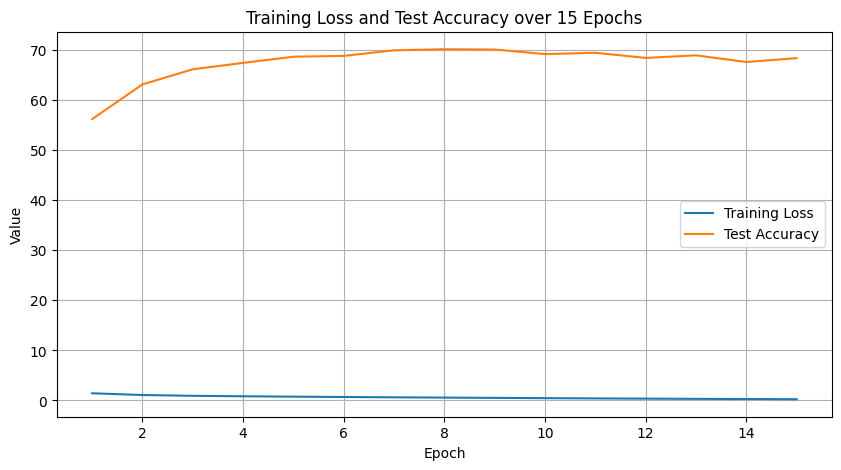

In [34]:
# Plotting training loss and test accuracy
epochs_range = range(1, EPOCHS_EX8 + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Loss and Test Accuracy over 15 Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Analysis of Divergence Point:**

After plotting the training loss and test accuracy, we can observe the trend:
*   **Training Loss:** Continuously decreases over the 15 epochs, indicating the model is learning from the training data.
*   **Test Accuracy:** Typically increases for an initial number of epochs and then might start to plateau or even decrease if overfitting occurs.

The divergence point is the epoch where the test accuracy starts to plateau or decline significantly, while the training loss continues to decrease. This indicates that the model is beginning to overfit the training data and generalize less effectively to unseen test data.

Based on the plot and the printed output, the test accuracy peaks at epoch 8 (70.20%) and then generally starts to fluctuate or decline, while the training loss continues to decrease. Therefore, the divergence, indicating potential overfitting, starts to become noticeable around **epoch 8**.

### Lab Exercise 9: Add RandomHorizontalFlip() to Training Transform

In [36]:
# Lab Exercise 9: Add transforms.RandomHorizontalFlip() to Training Transform

# Original transform (from Experiment 9) for comparison
original_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# New training transform with RandomHorizontalFlip
train_transform_ex9 = transforms.Compose([
    transforms.RandomHorizontalFlip(), # Add horizontal flip
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Update train_set and train_loader with the new transform
train_set_ex9 = torchvision.datasets.CIFAR10(root="./data", train=True,
                                         download=False, transform=train_transform_ex9)
train_loader_ex9 = torch.utils.data.DataLoader(train_set_ex9, batch_size=64, shuffle=True)

# Test set remains unchanged, using the original transform
test_set_ex9  = torchvision.datasets.CIFAR10(root="./data", train=False,
                                         download=False, transform=original_transform)
test_loader_ex9  = torch.utils.data.DataLoader(test_set_ex9,  batch_size=64, shuffle=False)

# Re-instantiate the original SmallCNN model for this exercise
model_ex9 = SmallCNN().to(device)
criterion_ex9 = nn.CrossEntropyLoss()
optimizer_ex9 = torch.optim.Adam(model_ex9.parameters(), lr=1e-3)
EPOCHS_EX9 = 5 # Retrain for 5 epochs

print("Starting training for SmallCNN with RandomHorizontalFlip...")
for epoch in range(1, EPOCHS_EX9 + 1):
    model_ex9.train()
    running_loss = 0.0
    for images, labels in train_loader_ex9:
        images, labels = images.to(device), labels.to(device)

        optimizer_ex9.zero_grad()
        outputs = model_ex9(images)
        loss = criterion_ex9(outputs, labels)
        loss.backward()
        optimizer_ex9.step()

        running_loss += loss.item() * images.size(0)

    print(f"epoch {epoch}   training loss {running_loss / len(train_set_ex9):.4f}")

print("Finished training for Lab Exercise 9.")

# Evaluate the model
model_ex9.eval()
correct_ex9 = 0
total_ex9 = 0

with torch.no_grad():
    for images, labels in test_loader_ex9:
        images, labels = images.to(device), labels.to(device)
        predicted = model_ex9(images).argmax(dim=1)
        correct_ex9 += (predicted == labels).sum().item()
        total_ex9   += labels.size(0)

accuracy_ex9 = 100 * correct_ex9 / total_ex9
print(f"Test accuracy with RandomHorizontalFlip: {accuracy_ex9:.2f}%")

# Report results
original_test_accuracy = 69.49 # From Experiment 11
print(f"Original test accuracy = {original_test_accuracy:.2f}%")
print(f"With RandomHorizontalFlip = {accuracy_ex9:.2f}%")
print(f"Change = {accuracy_ex9 - original_test_accuracy:.2f}%")

# Explanation for why flip is applied only to training data
# The flip is applied only to training data because it is a form of data augmentation.
# It creates additional variations during learning without changing the actual test examples.
# The test set should remain fixed so that evaluation measures performance on unseen, unmodified data.

Starting training for SmallCNN with RandomHorizontalFlip...
epoch 1   training loss 1.4455
epoch 2   training loss 1.1162
epoch 3   training loss 0.9817
epoch 4   training loss 0.8945
epoch 5   training loss 0.8217
Finished training for Lab Exercise 9.
Test accuracy with RandomHorizontalFlip: 70.21%
Original test accuracy = 69.49%
With RandomHorizontalFlip = 70.21%
Change = 0.72%


### Lab Exercise 10: Count MACs and Compare with Parameters

In [19]:
# Calculate MACs for conv1
H_out_conv1 = 32
W_out_conv1 = 32
K_conv1 = 3
C_in_conv1 = 3
C_out_conv1 = 16
MACs_conv1 = H_out_conv1 * W_out_conv1 * K_conv1 * K_conv1 * C_in_conv1 * C_out_conv1

print(f"MACs for conv1: {MACs_conv1}")

# Parameter count for conv1 (from Experiment 10 output)
params_conv1 = 432 + 16 # weights + bias
print(f"Parameters for conv1: {params_conv1}")

MACs for conv1: 442368
Parameters for conv1: 448


In [ ]:
# Calculate MACs for conv2
H_out_conv2 = 16
W_out_conv2 = 16
K_conv2 = 3
C_in_conv2 = 16
C_out_conv2 = 32
MACs_conv2 = H_out_conv2 * W_out_conv2 * K_conv2 * K_conv2 * C_in_conv2 * C_out_conv2

print(f"MACs for conv2: {MACs_conv2}")

# Parameter count for conv2 (from Experiment 10 output)
params_conv2 = 4608 + 32 # weights + bias
print(f"Parameters for conv2: {params_conv2}")

Comparing the two layers:

*   **conv1:**
    *   MACs: 442368
    *   Parameters: 448

*   **conv2:**
    *   MACs: 1179648
    *   Parameters: 4640

**Which layer is the more expensive?**
`conv2` is significantly more expensive in terms of Multiply-Accumulate Operations (MACs) with 1,179,648 MACs compared to `conv1`'s 442,368 MACs. This is because `conv2` processes a larger number of input channels (16) and produces more output channels (32) even though its feature map size is smaller (16x16 vs 32x32 for `conv1`). The `H_out * W_out * C_in * C_out` terms contribute significantly to the MACs.

**Which layer is the larger?**
`conv2` is also larger in terms of parameter count with 4,640 parameters compared to `conv1`'s 448 parameters. This is due to `conv2` having more input and output channels (`16 * 32` compared to `3 * 16`), which directly increases the number of weights, even though both use a 3x3 kernel.

In summary, `conv2` is both more computationally expensive and has a larger number of parameters than `conv1` in this `SmallCNN` architecture.

## Formulas Used in This Lab

| Quantity                    | Formula                                 | Verified in      |
|:----------------------------|:----------------------------------------|:-----------------|
| Convolution (cross-correlation) | `Z(i, j) = b + ΣΣ X(i+m, j+n) · K(m, n)` | Experiment 2     |
| ReLU activation             | `ReLU(z) = max(0, z)`                   | Experiment 4     |
|                             | `ddz ReLU(z) = 1 if z > 0,   0 if z < 0` |                  |
| Output size                 | `Hout = ⌊H + 2P − KS⌋ + 1`               | Experiment 3     |
| Same padding                | `P = K − 12   (K odd, S = 1)`             | Experiment 3     |
| Convolution parameters      | `K × K × Cin × Cout + Cout`             | Experiment 8     |
| Receptive field             | `rl = rl−1 + (kl − 1) · jl−1`           | Experiment 8     |
| Multiply-accumulate count   | `Hout × Wout × K × K × Cin × Cout`      | Experiment 8     |
| Bias gradient               | `∂L∂b = Σ  δ(i, j)`                     | Experiment 7     |
| Kernel gradient             | `∂L∂K = X ⊛ δ`                          | Experiment 7     |
| Input gradient              | `∂L∂X = δ ⊛ rot180(K)`                  | Experiment 7     |
| Max-pooling gradient        | `δ(i, j)  →  the argmax cell;  0 elsewhere` | Experiment 6     |
| Average-pooling gradient    | `δ(i, j)kh · kw  to every cell in the window` | Experiment 6     |